In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv("./survey.csv")

In [3]:
data.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [4]:
data.tail()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,...,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,...,Don't know,Yes,No,No,No,No,No,No,No,NaN
1258,2016-02-01 23:04:31,25,Male,United States,IL,No,Yes,Yes,Sometimes,26-100,...,Don't know,Maybe,No,Some of them,No,No,No,Don't know,No,NaN


In [5]:
data.shape

(1259, 27)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

<Axes: xlabel='Country'>

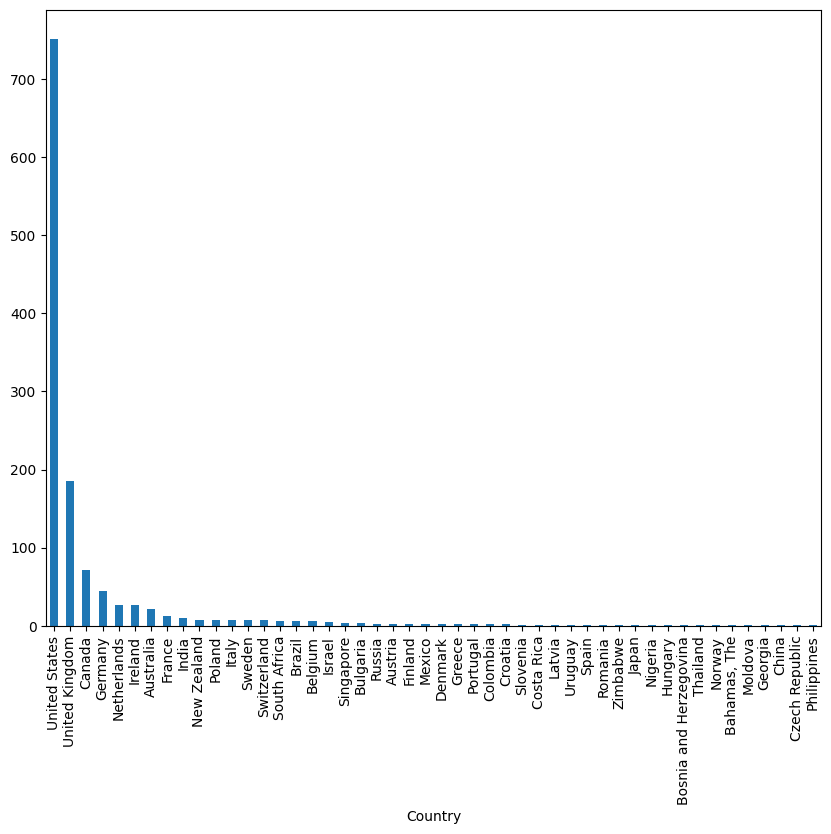

In [7]:
#Pre-Processing the Data
data['Country'].value_counts().plot(kind='bar', figsize=(10,8))

In [8]:
#Removing some columns as there informnation are not so relevalent.
data.drop(['Country','state', 'Timestamp','work_interfere','no_employees','comments','tech_company','benefits','wellness_program','seek_help','mental_health_consequence','phys_health_consequence','mental_health_interview','phys_health_interview','mental_vs_physical'], axis = 1, inplace=True)

In [9]:
#To check the null functions
data.isnull().sum()

Age                 0
Gender              0
self_employed      18
family_history      0
treatment           0
remote_work         0
care_options        0
anonymity           0
leave               0
coworkers           0
supervisor          0
obs_consequence     0
dtype: int64

In [10]:
# self_employed, work_interfere have null values.
#so we have to free the data set from null value [We are using fill NA function for this.]
data['self_employed'].value_counts()

self_employed
No     1095
Yes     146
Name: count, dtype: int64

In [11]:
data['self_employed'].fillna('No',inplace=True)
data['self_employed'].value_counts()

C:\Users\vasuk\AppData\Local\Temp\ipykernel_11596\108914557.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['self_employed'].fillna('No',inplace=True)


self_employed
No     1113
Yes     146
Name: count, dtype: int64

<Axes: xlabel='Age'>

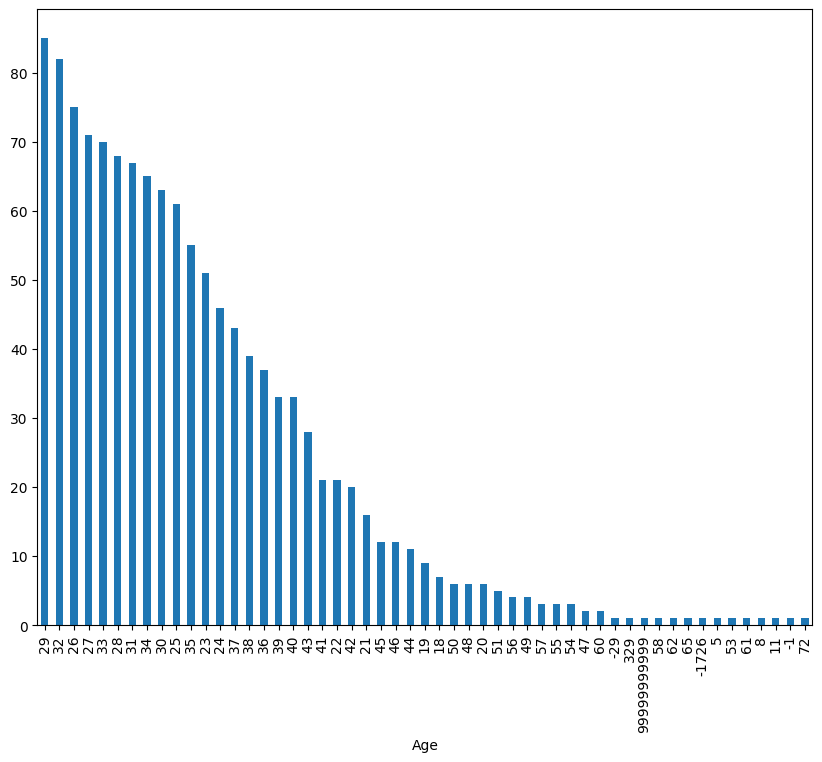

In [12]:
data['Age'].value_counts().plot(kind='bar', figsize=(10,8))

In [13]:
#In age/data-set there are some impractical entries are present so we have to remove them.
#Lets remove the rows with impractical entries
data.drop(data[(data['Age']>60) | (data['Age']<18)] .index, inplace=True)
data.to_csv('processed_data.csv', index=False)

<Axes: xlabel='Gender'>

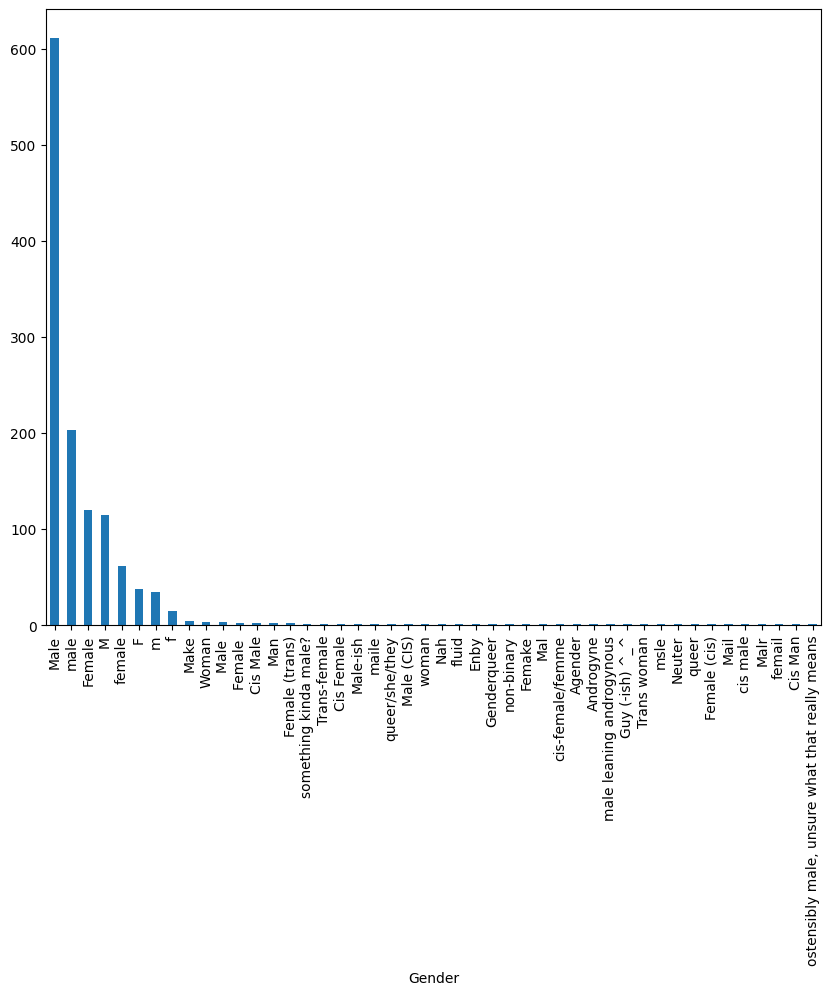

In [14]:
data['Gender'].value_counts().plot(kind='bar',figsize=(10,8))

In [15]:
#Here also we have to Group the gender in mainly 3 category.
# 1.Male, 2.Female, 3.Non-Binary

data['Gender'].replace([ 'Male', 'male', 'M', 'm', 'Male ',
                        'Cis Male', 'Man', 'cis male', 'Mail',
                        'Male-ish', 'Male (CIS)', 'Cis Man',
                        'msle', 'Malr', 'Mal', 'maile', 'Make', ], 'Male', inplace = True)

data['Gender'].replace([ 'Female ', 'female', 'F', 'f', 'Woman', 
                        'Female', 'femail', 'Cis Female', 'cis-female/femme', 
                        'Femake', 'Female (cis)', 'woman', ], 'Female', inplace = True)

data["Gender"].replace(['Female (trans)', 'queer/she/they', 'non-binary',
                        'fluid', 'queer', 'Androgyne', 'Trans-female', 
                        'male leaning androgynous', 'Agender', 'A little about you',
                        'Nah', 'All', 'ostensibly male, unsure what that really means',
                        'Genderqueer', 'Enby', 'p', 'Neuter', 'something kinda male?', 
                        'Guy (-ish) ^_^', 'Trans woman',], 'Non-Binary', inplace = True)

#After making 3 category it looks like
data['Gender'].value_counts()
#New Plot for Gender 
#data['Gender'].value_counts().plot(kind='bar',figsize=(10,8))

C:\Users\vasuk\AppData\Local\Temp\ipykernel_11596\20829814.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].replace([ 'Male', 'male', 'M', 'm', 'Male ',


Gender
Male          983
Female        246
Non-Binary     18
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution - Age')

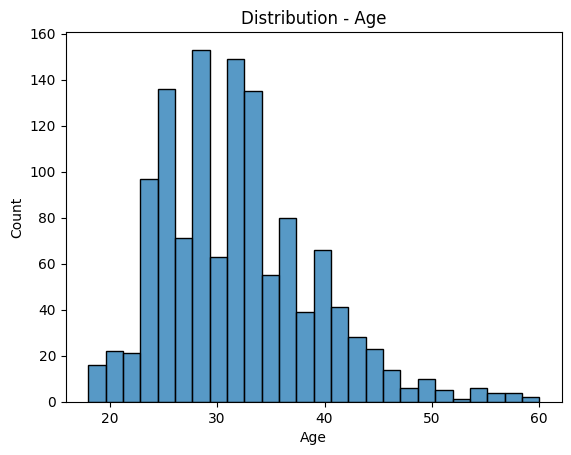

In [19]:
#Data Analysis and Visulization
sns.histplot(data["Age"])
#Provides distribution of specific features in our data set
plt.title("Distribution - Age")
plt.xlabel("Age") 
plt.title("Distribution - Age")




Text(0.5, 1.0, 'Employment Type')

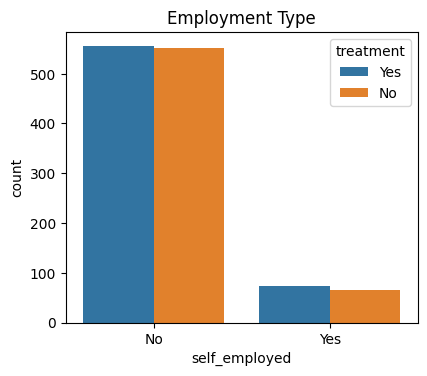

In [20]:
plt.figure(figsize=(10,40)) 
plt.subplot(9,2,1)
sns.countplot(data=data, x="self_employed", hue="treatment")
plt.title('Employment Type')

Text(0.5, 1.0, 'Family_History')

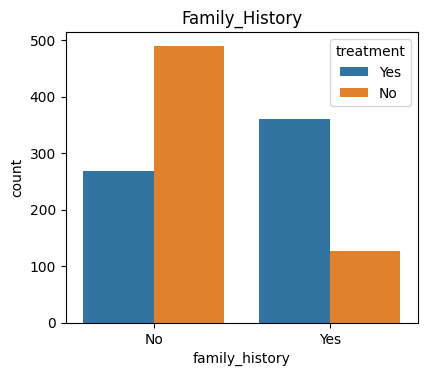

In [21]:
plt.figure(figsize=(10,40))
plt.subplot(9,2,2)
sns.countplot(data=data, x="family_history", hue="treatment")
plt.title('Family_History')

Text(0.5, 1.0, 'Work Type')

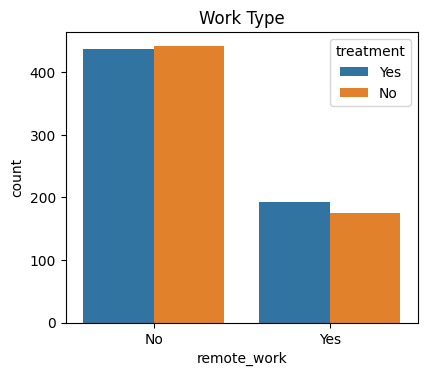

In [22]:
plt.figure(figsize=(10,40))
plt.subplot(9,2,4)
sns.countplot(data=data, x="remote_work", hue="treatment")
plt.title('Work Type')

Text(0.5, 1.0, 'Care Options')

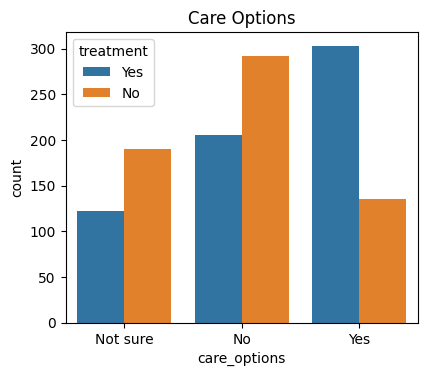

In [23]:
plt.figure(figsize=(10,40))
plt.subplot(9,2,7)
sns.countplot(data=data, x="care_options", hue="treatment")
plt.title('Care Options')


Text(0.5, 1.0, 'Anonymity')

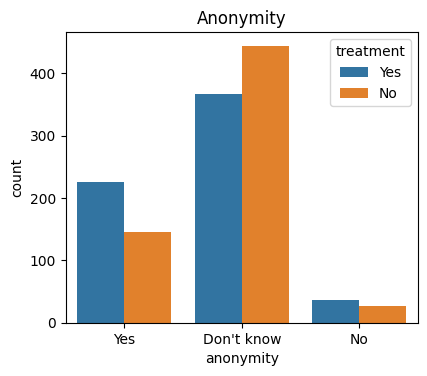

In [24]:
plt.figure(figsize=(10,40))
plt.subplot(9,2,10)
sns.countplot(data=data, x="anonymity", hue="treatment")
plt.title('Anonymity')


Text(0.5, 1.0, 'Leave')

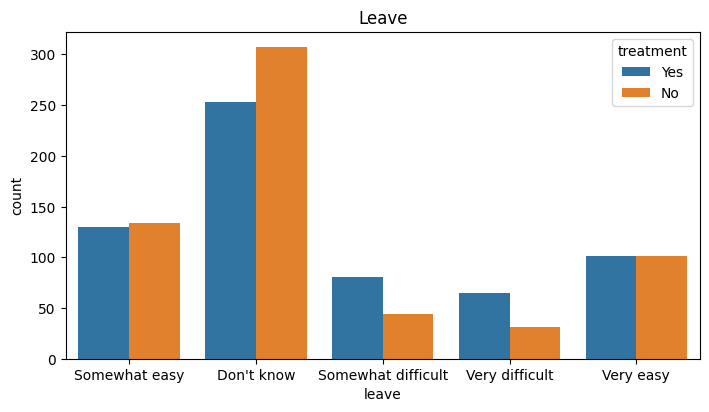

In [25]:
plt.figure(figsize=(18,45)) 
plt.subplot(9,2,11)
sns.countplot(data=data, x="leave", hue="treatment")
plt.title('Leave')

Text(0.5, 1.0, 'Discussion with Coworkers')

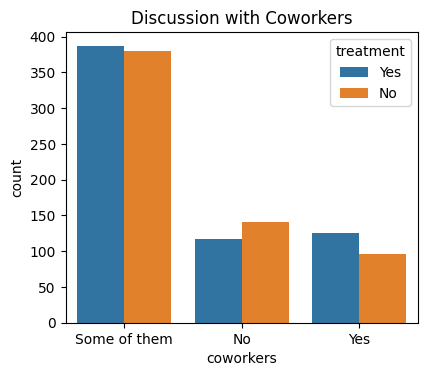

In [26]:
plt.figure(figsize=(10,40)) 
plt.subplot(9,2,14)
sns.countplot(data=data, x="coworkers", hue="treatment")
plt.title('Discussion with Coworkers')

Text(0.5, 1.0, 'Discussion With Supervisor')

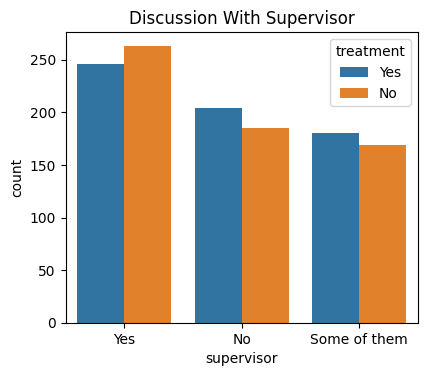

In [27]:
plt.figure(figsize=(10,40)) 
plt.subplot(9,2,15)
sns.countplot(data=data, x="supervisor", hue="treatment")
plt.title('Discussion With Supervisor')


Text(0.5, 1.0, 'Consequence After Disclosure')

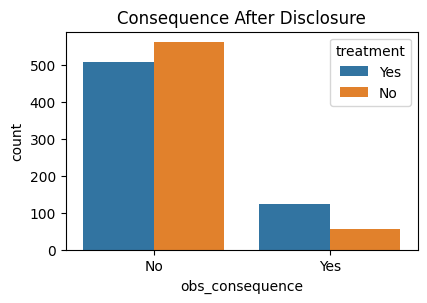

In [28]:
plt.figure(figsize=(10,30))
plt.subplot(9,2,18)
sns.countplot(data=data, x="obs_consequence", hue="treatment")
plt.title('Consequence After Disclosure')

In [29]:
data.describe(include='all')

,Age,Gender,self_employed,family_history,treatment,remote_work,care_options,anonymity,leave,coworkers,supervisor,obs_consequence
count,1247.000000,1247,1247,1247,1247,1247,1247,1247,1247,1247,1247,1247
unique,NaN,3,2,2,2,2,3,3,5,3,3,2
top,NaN,Male,No,No,Yes,No,No,Don't know,Don't know,Some of them,Yes,No
freq,NaN,983,1107,759,630,879,497,811,560,767,509,1068
mean,31.971131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7.052598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,27.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,36.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
X = data.drop('treatment', axis = 1)
y = data[ 'treatment']

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder 

In [33]:
ct = ColumnTransformer([('oe', OrdinalEncoder(), ['Gender', 'self_employed', 'family_history', 
                                                  'remote_work','care_options', 'anonymity',
                                                    'leave', 'coworkers', 'supervisor',            
                                                     'obs_consequence' ])],
                                                     remainder='passthrough')

In [34]:
x = ct.fit_transform(X)

In [35]:
le = LabelEncoder() 
y = le.fit_transform(y)

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=49)

In [37]:
X_train. shape, X_test.shape, y_train. shape, y_test.shape 

((872, 11), (375, 11), (872,), (375,))

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_curve, confusion_matrix, classification_report, auc 

In [56]:
model_dict = {}

model_dict['Logistic regression']= LogisticRegression(solver='liblinear', random_state=49)
model_dict ['Random Forest Classifier'] = RandomForestClassifier (random_state=49)
model_dict['KNN Classifier'] = KNeighborsClassifier() 
model_dict['Decision Tree Classifier'] = DecisionTreeClassifier (random_state=49)
model_dict['AdaBoost Classifier'] = AdaBoostClassifier (random_state=49)

# Gradient Boosting (Test)
model_dict ['Gradient Boosting Classifier'] = GradientBoostingClassifier (random_state=49) 
model_dict['XGB Classifier'] = XGBClassifier (random_state=49)

In [57]:
def model_test (X_train, X_test, y_train, y_test, model, model_name):
    model.fit(X_train,y_train) 
    y_pred = model.predict(X_test)
    accuracy = accuracy_score (y_test,y_pred)
    print('=============================={}==============================', format(model_name))
    print('Score is: {}'.format(accuracy))
    
    print()


In [58]:
for model_name, model in model_dict.items():
    model_test(X_train, X_test, y_train, y_test, model, model_name)

=============================={}============================== Logistic regression
Score is: 0.7466666666666667

=============================={}============================== Random Forest Classifier
Score is: 0.6986666666666667

=============================={}============================== KNN Classifier
Score is: 0.6426666666666667

=============================={}============================== Decision Tree Classifier
Score is: 0.6266666666666667

=============================={}============================== AdaBoost Classifier
Score is: 0.752

=============================={}============================== Gradient Boosting Classifier
Score is: 0.7253333333333334

=============================={}============================== XGB Classifier
Score is: 0.6533333333333333



In [45]:
Ada = AdaBoostClassifier (random_state=99) 
Ada.fit(X_train,y_train) 
pred_Ada = Ada.predict(X_test) 
print ('Accuracy of AdaBoost=', accuracy_score (y_test, pred_Ada))

Accuracy of AdaBoost= 0.752


In [46]:
from sklearn.model_selection import RandomizedSearchCV
params_Ada = {'n_estimators': [int(x) for x in np.linspace (start = 1, stop = 50, num =15)],
              'learning_rate': [(0.97 + x/ 100) for x in range(0, 8)],}

Ada_random = RandomizedSearchCV (random_state=49, estimator=Ada, param_distributions = params_Ada, n_iter = 50, cv = 5, n_jobs = -1)


In [47]:
params_Ada

{'n_estimators': [1, 4, 8, 11, 15, 18, 22, 25, 29, 32, 36, 39, 43, 46, 50],
 'learning_rate': [0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04]}

In [48]:
Ada_random.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=99)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.97, 0.98, ...], 'n_estimators': [1, 4, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fo

In [49]:
Ada_random.best_params_

{'n_estimators': 43, 'learning_rate': 0.98}

In [50]:
Ada_tuned = AdaBoostClassifier(random_state=99,n_estimators=43, learning_rate=0.98)
Ada_tuned.fit(X_train,y_train)
pred_Ada_tuned = Ada_tuned.predict(X_test) 
print('Accuracy of Adaboost (tuned)=', accuracy_score (y_test, pred_Ada_tuned))

Accuracy of Adaboost (tuned)= 0.7546666666666667


Text(50.722222222222214, 0.5, 'Actual')

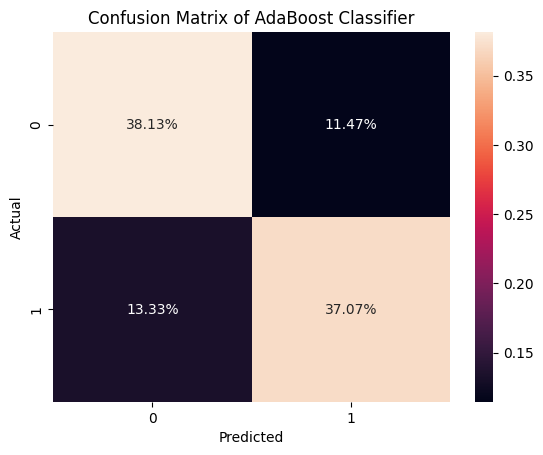

In [51]:
cf_matrix = confusion_matrix (y_test, pred_Ada)
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, fmt='.2%')
plt.title('Confusion Matrix of AdaBoost Classifier')
plt.xlabel('Predicted')
plt.ylabel ('Actual')

In [100]:
# from sklearn import metrics
# fpr_Ada, tpr_Ada, thresholds_Ada = roc_curve (y_test, pred_Ada)
# roc_auc_Ada = metrics.auc (fpr_Ada, tpr_Ada)
# plt.plot(fpr_Ada, tpr_Ada, color='orange', label='ROC curve (area = %0.2f)' % roc_auc_Ada)
# plt.plot([0, 1], [0, 1], color='blue', linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.0])
# plt.title('ROC Curve')
# plt.xlabel('False Positive Rate (1 - specifity)')
# plt.ylabel('True Positive Rate (sensitivity)')
# plt.legend (loc= "lower right")
# plt.show()
# roc_curve (y_test, pred_Ada)

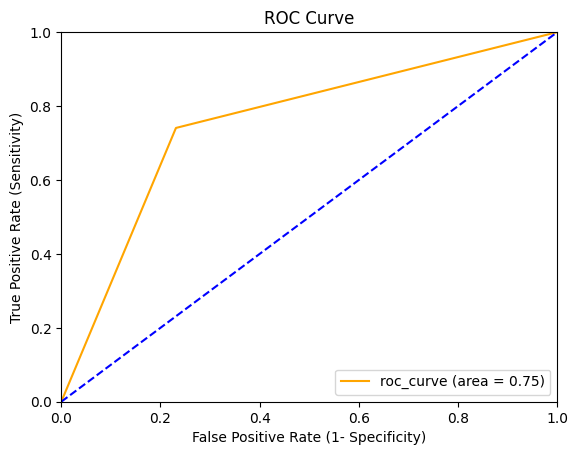

(array([0.       , 0.2311828, 1.       ]),
 array([0.        , 0.74074074, 1.        ]),
 array([inf,  1.,  0.]))

In [52]:
from sklearn.metrics import auc
fpr_Ada_tuned, tpr_Ada_tuned, thresholds_Ada_tuned = roc_curve (y_test, pred_Ada_tuned) 
roc_auc_Ada_tuned =auc(fpr_Ada_tuned, tpr_Ada_tuned) 
plt.plot(fpr_Ada_tuned, tpr_Ada_tuned, color='orange', label='roc_curve (area = %0.2f)' % roc_auc_Ada_tuned)
plt.plot([0, 1], [0, 1], color='blue', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (1- Specificity)') 
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend (loc= "lower right")
plt.show()
roc_curve (y_test, pred_Ada_tuned)

In [53]:
print(classification_report (y_test, pred_Ada))

              precision    recall  f1-score   support

           0       0.74      0.77      0.75       186
           1       0.76      0.74      0.75       189

    accuracy                           0.75       375
   macro avg       0.75      0.75      0.75       375
weighted avg       0.75      0.75      0.75       375



In [54]:
print(classification_report (y_test, pred_Ada_tuned))

              precision    recall  f1-score   support

           0       0.74      0.77      0.76       186
           1       0.77      0.74      0.75       189

    accuracy                           0.75       375
   macro avg       0.75      0.75      0.75       375
weighted avg       0.75      0.75      0.75       375



In [55]:
import pickle
pickle.dump(Ada_tuned, open('./model.pkl', 'wb'))
pickle.dump(ct, open('./ct.pkl', 'wb'))
pickle.dump(le, open('./le.pkl', 'wb'))
model=pickle.load(open('./model.pkl','rb'))